# Section 5: Optimal Model Selection
### Lecture 18: Threshold Optimization using Total Cost of Fraud

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('../Modulo2/creditcard.csv.zip')
y = df['Class']
X = df.drop(['Class','Amount','Time'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
#model_xgb = xgb.XGBClassifier(max_depth=5, scale_pos_weight=100)
model_xgb = xgb.XGBClassifier(max_depth=4, scale_pos_weight=100)
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[28424,     8],
       [    7,    42]])

XGBOOST classification

In [14]:
conf_matrix_xgb=confusion_matrix(y_test, y_pred)

print('True negatives TN - actually non-fraudulent and correctly classified as non-fraudulent')
print(conf_matrix_xgb[0][0]) #normal 
print('False positives FP - actually non-fraudulent but incorrectly classified as fraud')
print(conf_matrix_xgb[0][1]) # normal but predicted fraud 
print('False negatives FN - actually fraud but incorrectly classified as being non-fraudulent')
print(conf_matrix_xgb[1][0]) # fraud but predicted normal 
print('True positives TP - actually fraud and correctly classified as fraud')
print(conf_matrix_xgb[1][1]) # Fraud 

True negatives TN - actually non-fraudulent and correctly classified as non-fraudulent
28424
False positives FP - actually non-fraudulent but incorrectly classified as fraud
8
False negatives FN - actually fraud but incorrectly classified as being non-fraudulent
7
True positives TP - actually fraud and correctly classified as fraud
42


In [15]:
# probability of being fraudulent
y_pred = model_xgb.predict_proba(X_test)
y_pred

array([[9.9991751e-01, 8.2496219e-05],
       [9.9999869e-01, 1.3255234e-06],
       [9.9999470e-01, 5.3313283e-06],
       ...,
       [9.9999362e-01, 6.3598222e-06],
       [9.9999762e-01, 2.3700036e-06],
       [9.9999464e-01, 5.3437839e-06]], dtype=float32)

Coluna	Significado
    
[:,0]	Probabilidade de a amostra ser da classe 0

[:,1]	Probabilidade de a amostra ser da classe 1  <= usamos este

#### [:,1] → pega só a probabilidade de ser classe 1 (a classe "positiva").

In [16]:
# probability of being fraudulent
y_pred = model_xgb.predict_proba(X_test)[:,1]
y_pred

array([8.2496219e-05, 1.3255234e-06, 5.3313283e-06, ..., 6.3598222e-06,
       2.3700036e-06, 5.3437839e-06], dtype=float32)

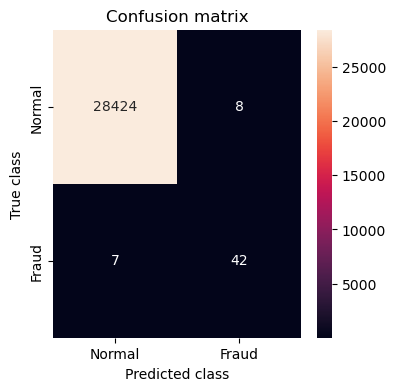

In [17]:
LABELS = ["Normal", "Fraud"]

plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix_xgb, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

### 1. Importações


numpy → para criar os thresholds (limiares de decisão).

average_precision_score → não é usado nesse código (sobrou da versão anterior).

In [18]:

import numpy as np
from sklearn.metrics import average_precision_score


## 2. Listas para armazenar resultados

threshold_list = []
tcf_list = []


threshold_list → guarda cada threshold testado (entre 0 e 1).

tcf_list → guarda o Total Cost of Fraud calculado em cada threshold.

### 3. Definição dos custos

cost_tn = 1
cost_fp = 10
cost_fn = 100
cost_tp = 1


0 = sem fraude

1 = com fraude

Define o custo associado a cada tipo de decisão:
----------------------------------------------
===============================================

Caso (da matriz de confusão) |	Nome	| Custo

Previu 0 e era 0 |	Verdadeiro Negativo (TN) |	cost_tn

Previu 1 e era 0 |	Falso Positivo (FP) |cost_fp

Previu 0 e era 1 |	Falso Negativo (FN)	| cost_fn

Previu 1 e era 1 |	Verdadeiro Positivo (TP) |	cost_tp

==========================================

💡 Exemplo no contexto de fraude:

FN (deixar passar uma fraude) custa muito caro → 100.

FP (bloquear cliente legítimo) também custa, mas menos → 10.

TN e TP podem até ter custo neutro (1 só para evitar zero).

In [19]:


threshold_list = []
tcf_list = []
cost_tn = 1
cost_fp = 10
cost_fn = 100
cost_tp = 1

### 4. Definição dos thresholds

thresholds = np.linspace(0, 1, 100)


Gera 100 valores de thresholds entre 0 e 1.

Para cada threshold, o modelo vai transformar a probabilidade em uma previsão binária (0 ou 1).

In [20]:
thresholds = np.linspace(0, 1, 100) # em  porcentagem


### 5. Loop para calcular o custo

In [21]:
for threshold in thresholds:
    y_pred_thresh = [1 if e > threshold else 0 for e in y_pred]
    threshold_list.append(threshold)

    # Total Cost of Fraud
    conf_matrix_xgb = confusion_matrix(y_test, y_pred_thresh)
    tcf_score = (conf_matrix_xgb[0][0] * cost_tn) + (conf_matrix_xgb[0][1] * cost_fp) + (conf_matrix_xgb[1][0] * cost_fn) + (conf_matrix_xgb[1][1] * cost_tp)
    tcf_list.append(tcf_score)


y_pred_thresh → converte probabilidades em classificações (1 se for maior que o threshold, senão 0).

- confusion_matrix → gera a matriz de confusão do modelo com aquele threshold.

- tcf_score → calcula o custo total:

### Cálculo do Total Cost of Fraud (TCF)

A matriz de confusão é:

|               | Predito = 0 | Predito = 1 |
|---------------|-------------|-------------|
| **Real = 0**  | TN          | FP          |
| **Real = 1**  | FN          | TP          |

E o custo total é dado por:

$\[
TCF = (TN \cdot C_{TN}) + (FP \cdot C_{FP}) + (FN \cdot C_{FN}) + (TP \cdot C_{TP})
\]$

Onde:

- $\( C_{TN} \)$ = custo de um verdadeiro negativo
- 
- $\( C_{FP} \)$ = custo de um falso positivo
- 
- $\( C_{FN} \)$ = custo de um falso negativo
- 
- $\( C_{TP} \)$ = custo de um verdadeiro positivo  
                                                           
- Guarda o threshold e o custo associado.

In [25]:
# plot curve
threshold_df = pd.DataFrame(threshold_list, tcf_list).reset_index()
threshold_df.columns = ['TCF', 'Threshold']

## correto 

In [26]:
threshold_df = pd.DataFrame({
    'Threshold': threshold_list,
    'TCF': tcf_list
})

threshold_df.head(20)

,Threshold,TCF
0,0.000000,284369
1,0.010101,30407
2,0.020202,29804
3,0.030303,29651
4,0.040404,29498
5,0.050505,29417
6,0.060606,29390
7,0.070707,29408
8,0.080808,29381
9,0.090909,29363


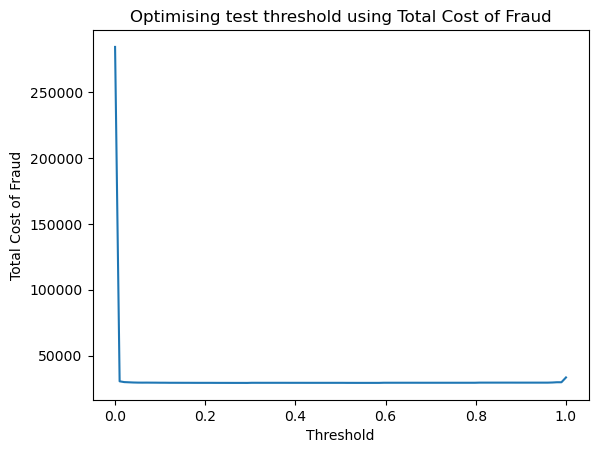

In [27]:


plt.plot(threshold_df['Threshold'], threshold_df['TCF'])
plt.title("Optimising test threshold using Total Cost of Fraud")
plt.xlabel('Threshold')
plt.ylabel('Total Cost of Fraud')
plt.savefig('Optimising threshold using Total Cost of Fraud');
plt.show()

In [29]:
# if threshold = 0, then everything is fraud (lots of false positives which cost $10 each)
# if threshold = 1, then everything is non-fraudulent (quite a few missed cases of fraud which cost $100 each)
# optimal threshold for this model is around 50% (already well balanced)

threshold_df.sort_values(by='TCF', ascending=True).head(5)

,Threshold,TCF
29,0.292929,29174
27,0.272727,29192
28,0.282828,29192
26,0.262626,29192
25,0.252525,29201


In [23]:
# if threshold = 0, then everything is fraud (lots of false positives which cost $10 each)
# if threshold = 1, then everything is non-fraudulent (quite a few missed cases of fraud which cost $100 each)
# optimal threshold for this model is around 50% (already well balanced)

threshold_df.sort_values(by='TCF', ascending=True)

,TCF,Threshold
29,29174,0.292929
27,29192,0.272727
28,29192,0.282828
26,29192,0.262626
25,29201,0.252525
...,...,...
97,29687,0.979798
2,29804,0.020202
1,30407,0.010101
99,33332,1.000000


In [30]:
error_df = pd.DataFrame(y_pred, y_test).reset_index()
error_df.columns = ['Target variable', 'Score']
error_df.to_csv('error_df.csv')

In [31]:
error_df.tail()

,Target variable,Score
28476,0,0.005059
28477,0,0.000190
28478,0,0.000006
28479,0,0.000002
28480,0,0.000005


In [32]:
error_df.head()

,Target variable,Score
0,0,0.000082
1,0,0.000001
2,0,0.000005
3,0,0.000004
4,0,0.000007



O índice resetado → que é y_test.

Os dados (y_pred) previsão probabilística.

Essas colunas são renomeadas para:

'Target variable' → os valores reais (y_test).

'Score' → os valores previstos (y_pred).


O valor real da variável alvo (y_test).

O valor previsto pelo modelo (y_pred).